# Applied Data Science and Machine Learning
## A program by IIT Madras and TalentSprint
### Mini Project: Healthcare classification

## About Dataset
###Context:
This synthetic healthcare dataset has been created to serve as a valuable resource for data science, machine learning, and data analysis enthusiasts. It is designed to mimic real-world healthcare data, enabling users to practice, develop, and showcase their data manipulation and analysis skills in the context of the healthcare industry.

###Inspiration:
The inspiration behind this dataset is rooted in the need for practical and diverse healthcare data for educational and research purposes. Healthcare data is often sensitive and subject to privacy regulations, making it challenging to access for learning and experimentation. To address this gap, I have leveraged Python's Faker library to generate a dataset that mirrors the structure and attributes commonly found in healthcare records. By providing this synthetic data, I hope to foster innovation, learning, and knowledge sharing in the healthcare analytics domain.

###Dataset Information:
Each column provides specific information about the patient, their admission, and the healthcare services provided, making this dataset suitable for various data analysis and modeling tasks in the healthcare domain. Here's a brief explanation of each column in the dataset


* **Name**: This column represents the name of the patient associated with the
healthcare record.
* **Age**: The age of the patient at the time of admission, expressed in years.
* **Gender**: Indicates the gender of the patient, either "Male" or "Female."
* **Blood Type**: The patient's blood type, which can be one of the common blood types (e.g., "A+", "O-", etc.).
* **Medical Condition**: This column specifies the primary medical condition or diagnosis associated with the patient, such as "Diabetes," "Hypertension," "Asthma," and more.
* **Date of Admission**: The date on which the patient was admitted to the healthcare facility.
* **Doctor**: The name of the doctor responsible for the patient's care during their admission.
* **Hospital**: Identifies the healthcare facility or hospital where the patient was admitted.
* **Insurance Provider**: This column indicates the patient's insurance provider, which can be one of several options, including "Aetna," "Blue Cross," "Cigna," "UnitedHealthcare," and "Medicare."
* **Billing Amount**: The amount of money billed for the patient's healthcare services during their admission. This is expressed as a floating-point number.
* **Room Number**: The room number where the patient was accommodated during their admission.
* **Admission Type**: Specifies the type of admission, which can be "Emergency," "Elective," or "Urgent," reflecting the circumstances of the admission.
* **Discharge Date**: The date on which the patient was discharged from the healthcare facility, based on the admission date and a random number of days within a realistic range.
* **Medication**: Identifies a medication prescribed or administered to the patient during their admission. Examples include "Aspirin," "Ibuprofen," "Penicillin," "Paracetamol," and "Lipitor."
* **Test Results**: Describes the results of a medical test conducted during the patient's admission. Possible values include "Normal," "Abnormal," or "Inconclusive," indicating the outcome of the test.

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import necessary libraries for machine learning
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder, OneHotEncoder #Label Encoder/One Hot Encoder
from sklearn.metrics import confusion_matrix #Confusion Matrix

## Load the csv file ( 1 Mark)

In [3]:
# Read dataset
data = pd.read_csv(r"D:\Firefox downloads\healthcare_dataset.csv")

In [4]:
# Print the top 5 data points
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Data Exploration ( 2 Marks)

In [5]:
# Print the type of data points
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
# Print the shape of data points
data.shape

(55500, 15)

In [7]:
# Print the missing values of each data point
data.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [8]:
# Identify and Print the numerical and categorical features
numerical_features = data.select_dtypes(include=[np.number]).columns 
categorical_features = data.select_dtypes(include=[object]).columns

print("Numerical Features: ", numerical_features)
print("Categorical Features: ", categorical_features)



Numerical Features:  Index(['Age', 'Billing Amount', 'Room Number'], dtype='object')
Categorical Features:  Index(['Name', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Admission Type', 'Discharge Date', 'Medication', 'Test Results'],
      dtype='object')


## Data Visualization ( 2 Marks)

c:\Users\ravis\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


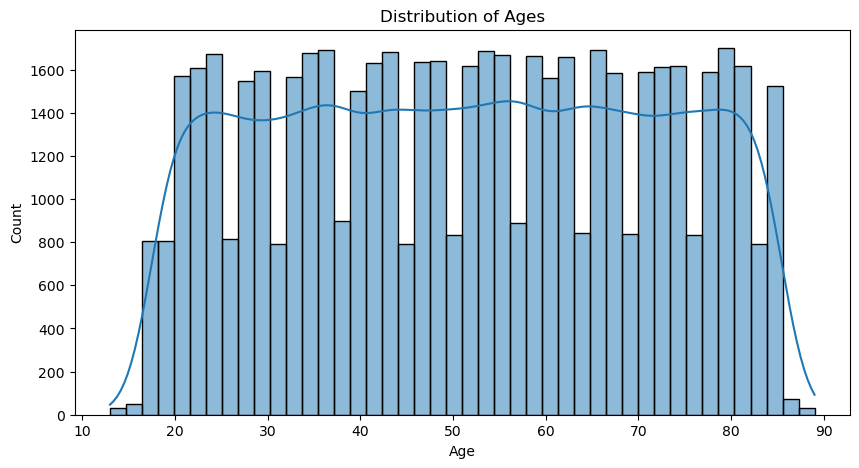

In [9]:
# Display the distribution of ages in histogram
plt.figure(figsize=(10,5))
sns.histplot(data['Age'], kde=True)
plt.title('Distribution of Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Assuming target is Test Results

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


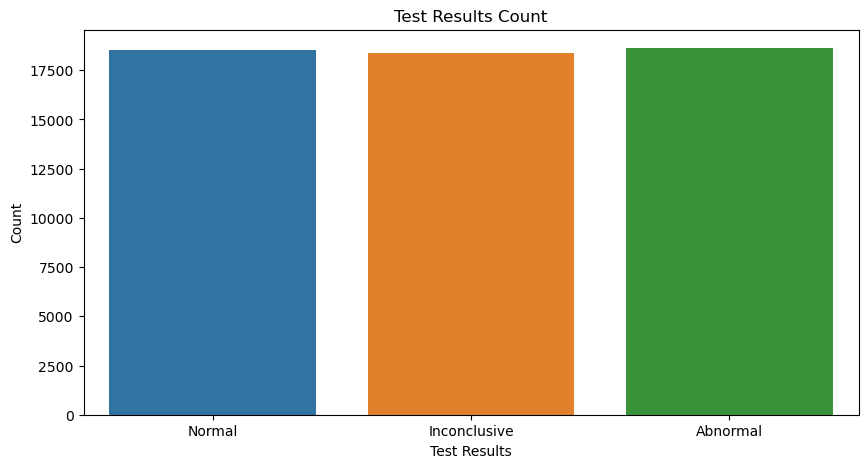

In [10]:
# Analyzing categories count of Target column
print(data['Test Results'].value_counts())

# Plot the value_counts of Medication column
plt.figure(figsize=(10,5))
sns.countplot(x = data['Test Results'], data=data)
plt.title('Test Results Count')
plt.xlabel('Test Results')
plt.ylabel('Count')
plt.show()



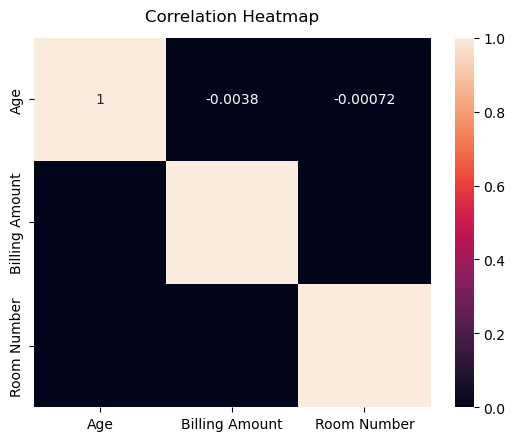

In [11]:
# Identify the numerical columns
numeric_data = data.select_dtypes(include=[np.number]) 

# Store heatmap object in a variable to easily access it when you want to include more features (such as title).
heatmap = sns.heatmap(numeric_data.corr(),vmin=0, vmax=1, annot=True)

# Give a title to the heatmap. Pad defines the distance of the title from the top of the heatmap.
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12)

# Display the heatmap
plt.show(heatmap)


## Preprocessing Data ( 2 Marks)

In [12]:
# Convert the categorical data to numerical :Label Encoding
def encode_features(dataframe, categorical_features):
    # Create a label encoder object
    le = LabelEncoder()
    
    # Iterate through the columns
    for feature in categorical_features:
        dataframe[feature] = le.fit_transform(dataframe[feature])
    
    return dataframe

encode_features(data, categorical_features)
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,3068,30,1,5,2,1729,26612,29933,1,18856.281306,328,2,1730,3,2
1,15211,62,1,0,5,104,33648,16012,3,33643.327287,265,1,109,1,1
2,6476,76,0,1,5,1233,37828,5473,0,27955.096079,205,1,1247,0,2
3,26935,28,0,6,3,560,22511,12317,3,37909.782410,450,0,589,1,0
4,26241,43,0,2,2,1230,21259,33598,0,14238.317814,458,2,1249,4,0


In [13]:
# Apply One Hot Encoding on 'Blood Type', 'Medical Condition', 'Admission Type', 'Medication'

def apply_one_hot_encoding(dataframe):    
    # Create a one hot encoder object
    ohe = OneHotEncoder()
    
    # Apply one hot encoding on the categorical columns
    blood_type = pd.DataFrame(ohe.fit_transform(dataframe[['Blood Type']]).toarray())
    medical_condition = pd.DataFrame(ohe.fit_transform(dataframe[['Medical Condition']]).toarray())
    admission_type = pd.DataFrame(ohe.fit_transform(dataframe[['Admission Type']]).toarray())
    medication = pd.DataFrame(ohe.fit_transform(dataframe[['Medication']]).toarray())
    
    # Rename the columns
    blood_type = blood_type.add_prefix('Blood Type ')
    medical_condition = medical_condition.add_prefix('Medical Condition ')
    admission_type = admission_type.add_prefix('Admission Type ')
    medication = medication.add_prefix('Medication ')
    
    # Drop the original columns
    dataframe = dataframe.drop(['Blood Type', 'Medical Condition', 'Admission Type', 'Medication'], axis=1)
    
    # Concatenate the dataframes
    dataframe = pd.concat([dataframe, blood_type, medical_condition, admission_type, medication], axis=1)
    
    return dataframe

data = apply_one_hot_encoding(data)
data.head()


,Name,Age,Gender,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Discharge Date,...,Medical Condition 4,Medical Condition 5,Admission Type 0,Admission Type 1,Admission Type 2,Medication 0,Medication 1,Medication 2,Medication 3,Medication 4
0,3068,30,1,1729,26612,29933,1,18856.281306,328,1730,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,15211,62,1,104,33648,16012,3,33643.327287,265,109,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,6476,76,0,1233,37828,5473,0,27955.096079,205,1247,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,26935,28,0,560,22511,12317,3,37909.782410,450,589,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,26241,43,0,1230,21259,33598,0,14238.317814,458,1249,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [17]:
data.columns

Index(['Age', 'Gender', 'Date of Admission', 'Discharge Date', 'Test Results',
       'Blood Type 0', 'Blood Type 1', 'Blood Type 2', 'Blood Type 3',
       'Blood Type 4', 'Blood Type 5', 'Blood Type 6', 'Blood Type 7',
       'Medical Condition 0', 'Medical Condition 1', 'Medical Condition 2',
       'Medical Condition 3', 'Medical Condition 4', 'Medical Condition 5',
       'Admission Type 0', 'Admission Type 1', 'Admission Type 2',
       'Medication 0', 'Medication 1', 'Medication 2', 'Medication 3',
       'Medication 4'],
      dtype='object')

In [16]:
# Identify and Drop the columns which are not useful for prediction of health
useless_columns = ['Name', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number']
data = data.drop(useless_columns, axis=1)
data.head()


,Age,Gender,Date of Admission,Discharge Date,Test Results,Blood Type 0,Blood Type 1,Blood Type 2,Blood Type 3,Blood Type 4,...,Medical Condition 4,Medical Condition 5,Admission Type 0,Admission Type 1,Admission Type 2,Medication 0,Medication 1,Medication 2,Medication 3,Medication 4
0,30,1,1729,1730,2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,62,1,104,109,1,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,76,0,1233,1247,2,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,28,0,560,589,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,43,0,1230,1249,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## Train/Test split dataset ( 1 Mark)

In [18]:
# Create X and y data
X = data.drop('Test Results', axis=1)
y = data['Test Results']

# Split the Data using sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model Training ( 2 Marks)

* Train you model on any 3 algorithms and predict the test data
* Confusion matrix
* Classification report

In [20]:
model1 = KNeighborsClassifier()
model1.fit(X_train, y_train)
print("trained KNN")

model2 = SVC()
model2.fit(X_train, y_train)
print("trained SVC")

model3 = GaussianNB()
model3.fit(X_train, y_train)
print("trained NB")

model4 = DecisionTreeClassifier()
model4.fit(X_train, y_train)
print("trained DT")

model5 = RandomForestClassifier()
model5.fit(X_train, y_train)
print("trained RF")


trained KNN
trained SVC
trained NB
trained DT
trained RF


In [21]:
# Predict the model on test data
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)
y_pred4 = model4.predict(X_test)
y_pred5 = model5.predict(X_test)

Confusion Matrix for KNN: 
 [[1851 1173  730]
 [1581 1299  737]
 [1560 1179  990]]


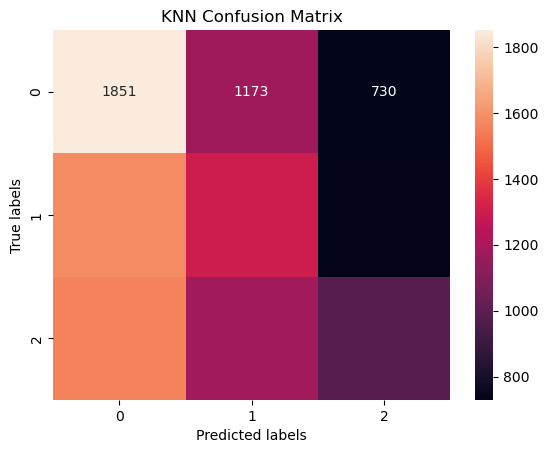

Confusion Matrix for SVC: 
 [[2646    0 1108]
 [2560    0 1057]
 [2554    0 1175]]


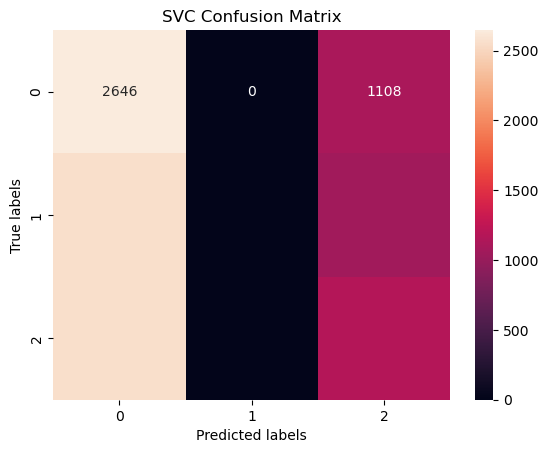

Confusion Matrix for GaussianNB: 
 [[1308 1268 1178]
 [1239 1220 1158]
 [1247 1273 1209]]


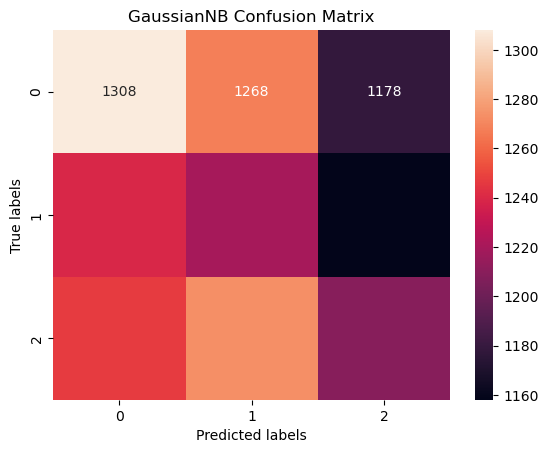

Confusion Matrix for DecisionTree: 
 [[1504 1151 1099]
 [1079 1472 1066]
 [1135 1032 1562]]


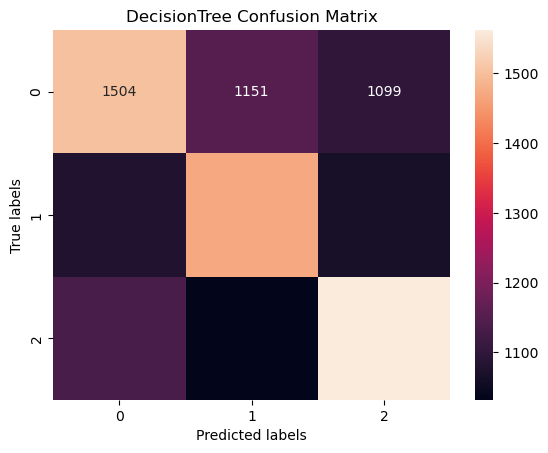

Confusion Matrix for RandomForest: 
 [[1659 1056 1039]
 [1074 1524 1019]
 [1075 1050 1604]]


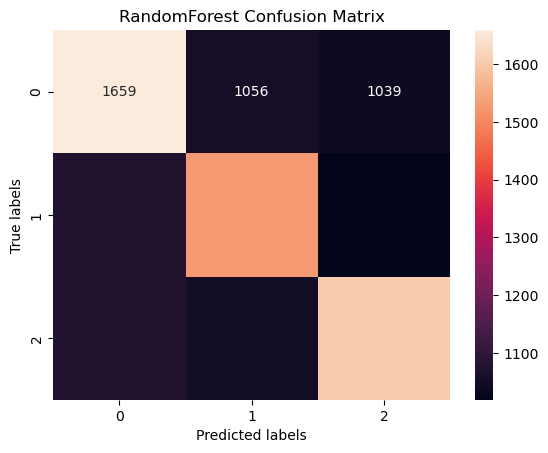

In [22]:
# YOUR CODE HERE: To visualise the confusion matrix
cm1 = confusion_matrix(y_test, y_pred1) 
print("Confusion Matrix for KNN: \n", cm1)
sns.heatmap(cm1, annot=True, fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('KNN Confusion Matrix')
plt.show()

cm2 = confusion_matrix(y_test, y_pred2)
print("Confusion Matrix for SVC: \n", cm2)  
sns.heatmap(cm2, annot=True, fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('SVC Confusion Matrix')
plt.show()

cm3 = confusion_matrix(y_test, y_pred3)
print("Confusion Matrix for GaussianNB: \n", cm3)
sns.heatmap(cm3, annot=True, fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('GaussianNB Confusion Matrix')
plt.show()

cm4 = confusion_matrix(y_test, y_pred4)
print("Confusion Matrix for DecisionTree: \n", cm4)
sns.heatmap(cm4, annot=True, fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('DecisionTree Confusion Matrix')
plt.show()

cm5 = confusion_matrix(y_test, y_pred5)
print("Confusion Matrix for RandomForest: \n", cm5)
sns.heatmap(cm5, annot=True, fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('RandomForest Confusion Matrix')
plt.show()


In [23]:
# YOUR CODE HERE: To print the classification report
def evaluate_model(model,X_test,y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Model: ", model)
    print("Accuracy: ", accuracy)
    print("Classification Report: \n", classification_report(y_test, y_pred))
    return 

for model in [model1, model2, model3, model4, model5]:
    evaluate_model(model,X_test,y_test)

Model:  KNeighborsClassifier()
Accuracy:  0.372972972972973
Classification Report: 
               precision    recall  f1-score   support

           0       0.37      0.49      0.42      3754
           1       0.36      0.36      0.36      3617
           2       0.40      0.27      0.32      3729

    accuracy                           0.37     11100
   macro avg       0.38      0.37      0.37     11100
weighted avg       0.38      0.37      0.37     11100

Model:  SVC()
Accuracy:  0.3442342342342342
Classification Report: 
               precision    recall  f1-score   support

           0       0.34      0.70      0.46      3754
           1       0.00      0.00      0.00      3617
           2       0.35      0.32      0.33      3729

    accuracy                           0.34     11100
   macro avg       0.23      0.34      0.26     11100
weighted avg       0.23      0.34      0.27     11100

Model:  GaussianNB()
Accuracy:  0.33666666666666667
Classification Report: 
        

c:\Users\ravis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ravis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ravis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Model:  RandomForestClassifier()
Accuracy:  0.43126126126126124
Classification Report: 
               precision    recall  f1-score   support

           0       0.44      0.44      0.44      3754
           1       0.42      0.42      0.42      3617
           2       0.44      0.43      0.43      3729

    accuracy                           0.43     11100
   macro avg       0.43      0.43      0.43     11100
weighted avg       0.43      0.43      0.43     11100



### Report Your Observations

Random Forest gives highest accuracy. Accuracy scores are less than 45%. More feature engineering could be done to improve the accuracy. One reason for low accuracy could be because the data is synthesised and not real-world data. 